# Discrete regularized Wasserstein transport and Sinkhorn debiasing

For discrete measures $\mu=\sum_i a_i\delta_{x_i}$ and $\nu=\sum_j b_j\delta_{y_j}$, this notebook compares:

1. standard (unregularized) optimal transport,
2. entropically regularized transport, and
3. the debiased Sinkhorn divergence.

The regularized objective is
$$\operatorname{OT}_\varepsilon(\mu,\nu)=\min_{P\in\Pi(a,b)}\langle C,P\rangle+\varepsilon\,\operatorname{KL}(P\mid a\otimes b).$$
Among all couplings with marginals $a,b$, the product coupling $a\otimes b$ uniquely maximizes Shannon entropy. Thus increasing $\varepsilon$ pulls the plan toward the product coupling: it becomes maximally spread out **in the entropy sense**, not necessarily in geometric distance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

## Two discrete measures

We use squared Euclidean transport cost $C_{ij}=|x_i-y_j|^2$.

In [2]:
x = np.array([-2.0, -0.25, 1.35])
a = np.array([0.20, 0.50, 0.30])
y = np.array([-1.35, 0.55, 2.15])
b = np.array([0.35, 0.25, 0.40])

def cost_matrix(support_1, support_2):
    return (support_1[:, None] - support_2[None, :]) ** 2

Cxy = cost_matrix(x, y)
product = np.outer(a, b)
Cxy

array([[ 0.4225,  6.5025, 17.2225],
       [ 1.21  ,  0.64  ,  5.76  ],
       [ 7.29  ,  0.64  ,  0.64  ]])

## Solvers and diagnostics

In [3]:
def exact_ot_plan(weights_1, weights_2, C):
    n, m = C.shape
    A_eq, rhs = [], []
    for i in range(n):
        row = np.zeros((n, m)); row[i, :] = 1
        A_eq.append(row.ravel()); rhs.append(weights_1[i])
    for j in range(m):
        row = np.zeros((n, m)); row[:, j] = 1
        A_eq.append(row.ravel()); rhs.append(weights_2[j])
    result = linprog(C.ravel(), A_eq=np.array(A_eq), b_eq=np.array(rhs),
                     bounds=(0, None), method='highs')
    if not result.success:
        raise RuntimeError(result.message)
    return result.x.reshape(n, m)

def sinkhorn_plan(weights_1, weights_2, C, epsilon, tol=1e-12, max_iter=20_000):
    K = np.exp(-C / epsilon)
    u = np.ones_like(weights_1)
    v = np.ones_like(weights_2)
    for _ in range(max_iter):
        old_u = u.copy()
        u = weights_1 / np.maximum(K @ v, 1e-300)
        v = weights_2 / np.maximum(K.T @ u, 1e-300)
        if np.max(np.abs(u - old_u)) < tol:
            break
    return (u[:, None] * K) * v[None, :]

def kl_to_product(P, weights_1, weights_2):
    Q = np.outer(weights_1, weights_2)
    mask = P > 0
    return np.sum(P[mask] * np.log(P[mask] / Q[mask]))

def regularized_ot(weights_1, weights_2, C, epsilon):
    P = sinkhorn_plan(weights_1, weights_2, C, epsilon)
    value = np.sum(C * P) + epsilon * kl_to_product(P, weights_1, weights_2)
    return value, P

def sinkhorn_divergence(x, a, y, b, epsilon):
    ot_xy, Pxy = regularized_ot(a, b, cost_matrix(x, y), epsilon)
    ot_xx, Pxx = regularized_ot(a, a, cost_matrix(x, x), epsilon)
    ot_yy, Pyy = regularized_ot(b, b, cost_matrix(y, y), epsilon)
    return ot_xy - 0.5 * ot_xx - 0.5 * ot_yy, (ot_xy, ot_xx, ot_yy), (Pxy, Pxx, Pyy)

def matrix_plot(ax, P, title, xlabel='target atom', ylabel='source atom'):
    im = ax.imshow(P, cmap='magma', vmin=0, vmax=max(P.max(), 1e-12))
    for (i, j), value in np.ndenumerate(P):
        ax.text(j, i, f'{value:.3f}', ha='center', va='center',
                color='white' if value > 0.45 * P.max() else 'black', fontsize=9)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticks(range(P.shape[1])); ax.set_yticks(range(P.shape[0]))
    return im

def edge_plot(ax, support_1, weights_1, support_2, weights_2, P, title):
    ax.scatter(support_1, np.ones_like(support_1), s=1000 * weights_1, c='tab:blue', label=r'$\mu$')
    ax.scatter(support_2, np.zeros_like(support_2), s=1000 * weights_2, c='tab:red', label=r'$\nu$')
    for i, sx in enumerate(support_1):
        for j, sy in enumerate(support_2):
            if P[i, j] > 1e-5:
                ax.plot([sx, sy], [1, 0], color='black', alpha=0.15 + 0.8 * P[i, j] / P.max(),
                        linewidth=0.5 + 10 * P[i, j])
    ax.set(title=title, yticks=[0, 1], yticklabels=[r'$\nu$', r'$\mu$'])
    ax.set_ylim(-0.2, 1.2)

## Standard OT, independent product, and regularized OT

The exact plan is sparse. The regularized plan trades transport cost against proximity to $a\otimes b$.

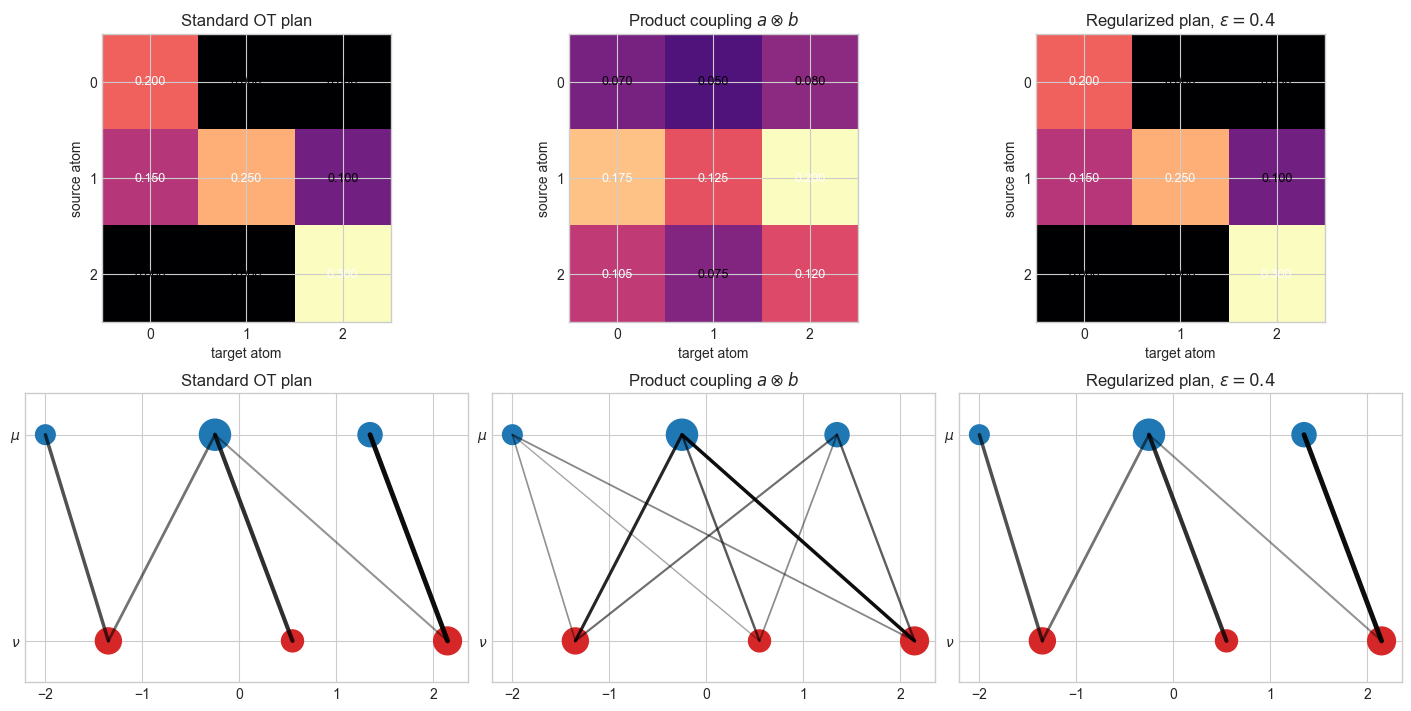

Standard transport cost: 1.194000
Regularized objective:    1.420280
KL(P_epsilon || a⊗b):    0.565672


In [4]:
epsilon = 0.40
P_standard = exact_ot_plan(a, b, Cxy)
ot_epsilon, P_epsilon = regularized_ot(a, b, Cxy, epsilon)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plans = [P_standard, product, P_epsilon]
titles = ['Standard OT plan', r'Product coupling $a\otimes b$', rf'Regularized plan, $\varepsilon={epsilon}$']
for ax, P, title in zip(axes[0], plans, titles):
    matrix_plot(ax, P, title)
for ax, P, title in zip(axes[1], plans, titles):
    edge_plot(ax, x, a, y, b, P, title)
plt.show()

print(f'Standard transport cost: {np.sum(Cxy * P_standard):.6f}')
print(f'Regularized objective:    {ot_epsilon:.6f}')
print(f'KL(P_epsilon || a⊗b):    {kl_to_product(P_epsilon, a, b):.6f}')

## Debiased Sinkhorn divergence

Regularized OT has a positive self-cost: generally $\operatorname{OT}_\varepsilon(\mu,\mu)>0$. The debiased quantity subtracts these self-costs:
$$S_\varepsilon(\mu,\nu)=\operatorname{OT}_\varepsilon(\mu,\nu)-\tfrac12\operatorname{OT}_\varepsilon(\mu,\mu)-\tfrac12\operatorname{OT}_\varepsilon(\nu,\nu).$$

There is no single separate ‘debiased plan’: debiasing combines the values of one cross-coupling and two self-couplings. The three plans are shown below.

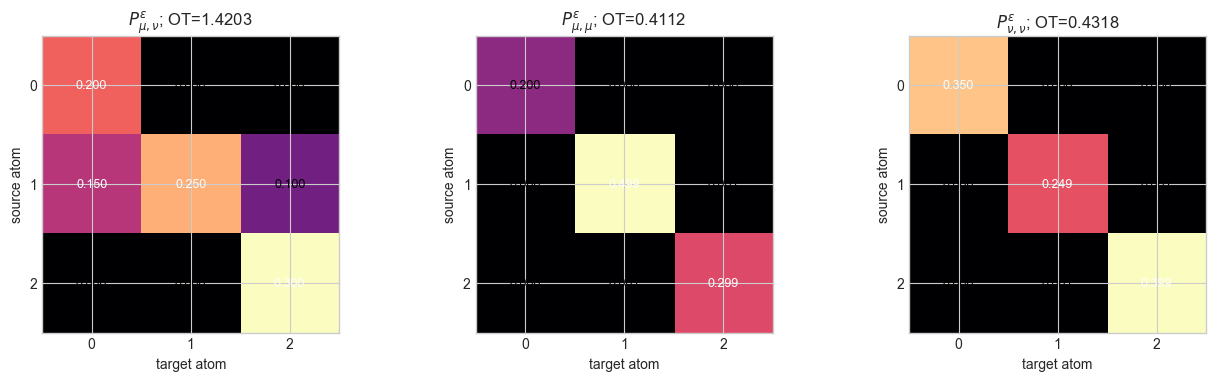

OT_epsilon(mu, nu) = 1.420280
OT_epsilon(mu, mu) = 0.411227
OT_epsilon(nu, nu) = 0.431763
Debiased S_epsilon = 1.420280 - 0.5(0.411227) - 0.5(0.431763) = 0.998785


In [5]:
S_epsilon, (OT_xy, OT_xx, OT_yy), (Pxy, Pxx, Pyy) = sinkhorn_divergence(x, a, y, b, epsilon)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), constrained_layout=True)
matrix_plot(axes[0], Pxy, rf'$P_{{\mu,\nu}}^\varepsilon$; OT={OT_xy:.4f}')
matrix_plot(axes[1], Pxx, rf'$P_{{\mu,\mu}}^\varepsilon$; OT={OT_xx:.4f}')
matrix_plot(axes[2], Pyy, rf'$P_{{\nu,\nu}}^\varepsilon$; OT={OT_yy:.4f}')
plt.show()

print(f'OT_epsilon(mu, nu) = {OT_xy:.6f}')
print(f'OT_epsilon(mu, mu) = {OT_xx:.6f}')
print(f'OT_epsilon(nu, nu) = {OT_yy:.6f}')
print(f'Debiased S_epsilon = {OT_xy:.6f} - 0.5({OT_xx:.6f}) - 0.5({OT_yy:.6f}) = {S_epsilon:.6f}')

## What happens as regularization increases?

The Frobenius distance to $a\otimes b$ and $\operatorname{KL}(P_\varepsilon\mid a\otimes b)$ both approach zero. This is the precise sense in which the plan becomes more spread out.

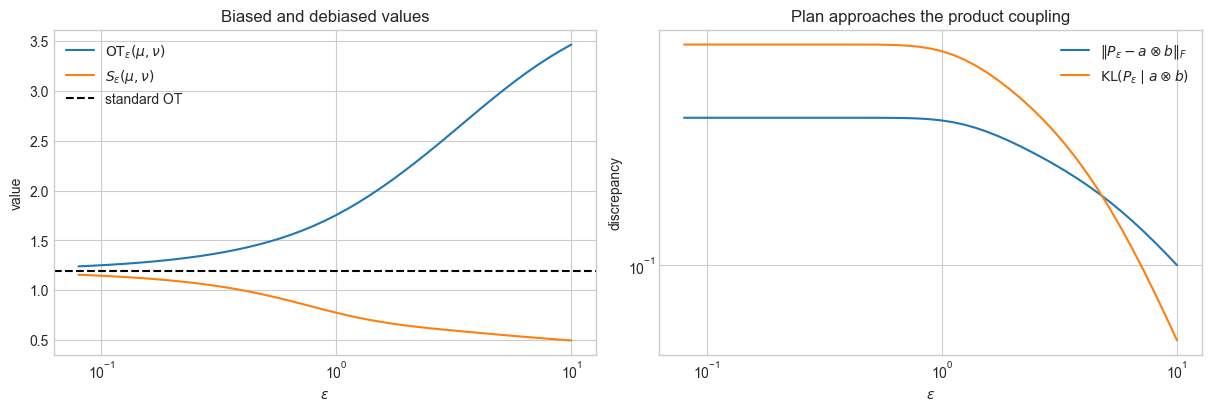

In [6]:
epsilons = np.geomspace(0.08, 10.0, 45)
regularized_values, debiased_values = [], []
distance_to_product, kl_values = [], []

for eps in epsilons:
    value, P = regularized_ot(a, b, Cxy, eps)
    S, _, _ = sinkhorn_divergence(x, a, y, b, eps)
    regularized_values.append(value)
    debiased_values.append(S)
    distance_to_product.append(np.linalg.norm(P - product))
    kl_values.append(kl_to_product(P, a, b))

standard_value = np.sum(Cxy * P_standard)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].semilogx(epsilons, regularized_values, label=r'$\mathrm{OT}_\varepsilon(\mu,\nu)$')
axes[0].semilogx(epsilons, debiased_values, label=r'$S_\varepsilon(\mu,\nu)$')
axes[0].axhline(standard_value, color='black', linestyle='--', label='standard OT')
axes[0].set(xlabel=r'$\varepsilon$', ylabel='value', title='Biased and debiased values')
axes[0].legend()

axes[1].loglog(epsilons, distance_to_product, label=r'$\|P_\varepsilon-a\otimes b\|_F$')
axes[1].loglog(epsilons, kl_values, label=r'$\mathrm{KL}(P_\varepsilon\mid a\otimes b)$')
axes[1].set(xlabel=r'$\varepsilon$', ylabel='discrepancy', title='Plan approaches the product coupling')
axes[1].legend()
plt.show()

### Takeaway

- $\varepsilon\to0$: the regularized plan approaches a standard optimal transport plan.
- Large $\varepsilon$: the KL term dominates and the plan approaches the independent product $a\otimes b$.
- $a\otimes b$ is the maximum-entropy coupling among couplings with the prescribed marginals.
- Debiasing removes the regularized self-cost at the level of divergence values; it does not define a new cross-transport plan.